# Differential Expression and Pathway Follow-up
This notebook generates thesis-facing figures and tables for FOXA2 differential expression analyses in LIHC.

Storyline:
1. Pathway-level contrast (lead figure)
2. Gene-level volcano summaries
3. Expression distributions for selected representative genes
4. Method agreement and sensitivity summaries


In [1]:
from pathlib import Path

import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'outputs' / 'experiments').exists():
    ROOT = ROOT.parent

EXP_ROOT = ROOT / 'outputs/experiments/lihc_foxa2_all_samples'
THESIS_ROOT = ROOT / 'outputs/thesis/03_differential_expression'
DATA_DIR = THESIS_ROOT / 'data'
FIG_DIR = THESIS_ROOT / 'figures'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DESEQ_PATH = EXP_ROOT / 'de_exp_decay_500k_spearman_r_linear_resid/differential_expression_results_all.csv'
LIMMA_PATH = EXP_ROOT / 'de_limma_exp_decay_500k_spearman_r_linear_resid/limma_results_all.csv'
LABELS_PATH = EXP_ROOT / 'de_exp_decay_500k_spearman_r_linear_resid/sample_labels_used.csv'
COUNTS_PATH = ROOT / 'data/raw/rna/TCGA-LIHC.star_counts.tsv'

STEP1_PATH = EXP_ROOT / 'de_followups_stepwise/step1_continuous_deseq_results.csv'
STEP2_PATH = EXP_ROOT / 'de_followups_stepwise/step2_fgsea_hallmark.csv'
STEP3_PATH = EXP_ROOT / 'de_followups_stepwise/step3_continuous_deseq_with_sva_results.csv'
STEP4_PATH = EXP_ROOT / 'de_followups_stepwise/step4_continuous_deseq_hallmark_universe_results.csv'
STEP5_PATH = EXP_ROOT / 'de_followups_stepwise/step5_limma_voom_binary_results.csv'

ALPHA = 0.05

for p in [DESEQ_PATH, LIMMA_PATH, STEP1_PATH, STEP2_PATH, STEP3_PATH, STEP4_PATH, STEP5_PATH, LABELS_PATH, COUNTS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required input: {p}')

deseq = pd.read_csv(DESEQ_PATH)
limma = pd.read_csv(LIMMA_PATH)
step1 = pd.read_csv(STEP1_PATH)
fgsea = pd.read_csv(STEP2_PATH)
step3 = pd.read_csv(STEP3_PATH)
step4 = pd.read_csv(STEP4_PATH)
step5 = pd.read_csv(STEP5_PATH)
labels = pd.read_csv(LABELS_PATH)

print('Loaded rows:')
print('DESeq2 binary:', len(deseq))
print('limma binary:', len(limma))
print('FGSEA Hallmark:', len(fgsea))
print('Samples with inferred labels:', len(labels))


Loaded rows:
DESeq2 binary: 9006
limma binary: 20218
FGSEA Hallmark: 50
Samples with inferred labels: 271


## 1) Pathway-Level Signal (FGSEA Hallmark, lead figure)


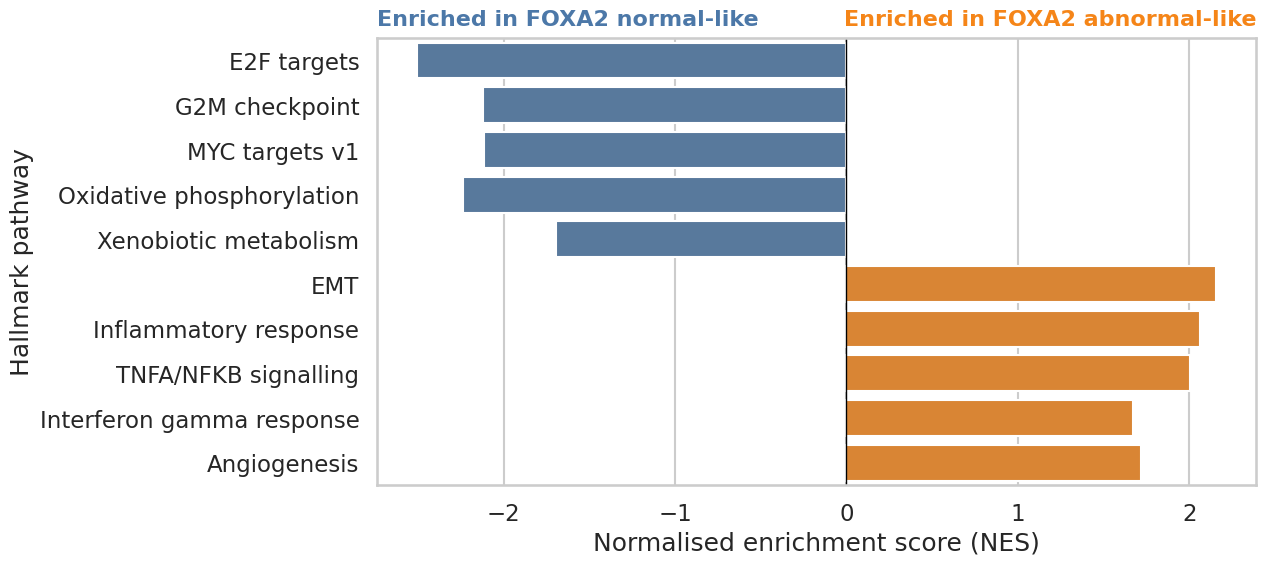

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/figures/01_pathway_nes_plot.png


In [2]:
fgsea = fgsea.copy()
fgsea['padj'] = pd.to_numeric(fgsea['padj'], errors='coerce')
fgsea['NES'] = pd.to_numeric(fgsea['NES'], errors='coerce')
fgsea['size'] = pd.to_numeric(fgsea['size'], errors='coerce')
fgsea['neg_log10_padj'] = -np.log10(fgsea['padj'])
fgsea['is_sig'] = fgsea['padj'] < ALPHA

label_map = {
    'HALLMARK_E2F_TARGETS': 'E2F targets',
    'HALLMARK_G2M_CHECKPOINT': 'G2M checkpoint',
    'HALLMARK_MYC_TARGETS_V1': 'MYC targets v1',
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION': 'Oxidative phosphorylation',
    'HALLMARK_XENOBIOTIC_METABOLISM': 'Xenobiotic metabolism',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION': 'EMT',
    'HALLMARK_INFLAMMATORY_RESPONSE': 'Inflammatory response',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB': 'TNFA/NFKB signalling',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE': 'Interferon gamma response',
    'HALLMARK_ANGIOGENESIS': 'Angiogenesis',
}

normal_like = [
    'HALLMARK_E2F_TARGETS',
    'HALLMARK_G2M_CHECKPOINT',
    'HALLMARK_MYC_TARGETS_V1',
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_XENOBIOTIC_METABOLISM',
]
abnormal_like = [
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
    'HALLMARK_INFLAMMATORY_RESPONSE',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE',
    'HALLMARK_ANGIOGENESIS',
]
selected_order = normal_like + abnormal_like

plot_df = fgsea[fgsea['pathway'].isin(selected_order)].copy()
plot_df['pathway'] = pd.Categorical(plot_df['pathway'], categories=selected_order, ordered=True)
plot_df = plot_df.sort_values('pathway').copy()
plot_df['pathway_label'] = plot_df['pathway'].map(label_map)
plot_df['direction'] = np.where(plot_df['NES'] > 0, 'Enriched in FOXA2 abnormal-like', 'Enriched in FOXA2 normal-like')

plot_df.to_csv(DATA_DIR / '03_fgsea_selected_pathways_for_lead_plot.csv', index=False)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=plot_df,
    y='pathway_label',
    x='NES',
    hue='direction',
    dodge=False,
    palette={
        'Enriched in FOXA2 abnormal-like': '#F58518',
        'Enriched in FOXA2 normal-like': '#4C78A8',
    },
    ax=ax,
)
ax.axvline(0.0, color='black', linewidth=1)
ax.set_xlabel('Normalised enrichment score (NES)')
ax.set_ylabel('Hallmark pathway')
ax.text(
    0.0,
    1.02,
    'Enriched in FOXA2 normal-like',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=16,
    fontweight='bold',
    color='#4C78A8',
)
ax.text(
    1.0,
    1.02,
    'Enriched in FOXA2 abnormal-like',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=16,
    fontweight='bold',
    color='#F58518',
)
ax.legend_.remove() if ax.legend_ is not None else None
plt.tight_layout()
out = FIG_DIR / '01_pathway_nes_plot.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', out)



## 2) Volcano Plots for Primary Binary Models


'select()' returned 1:1 mapping between keys and columns


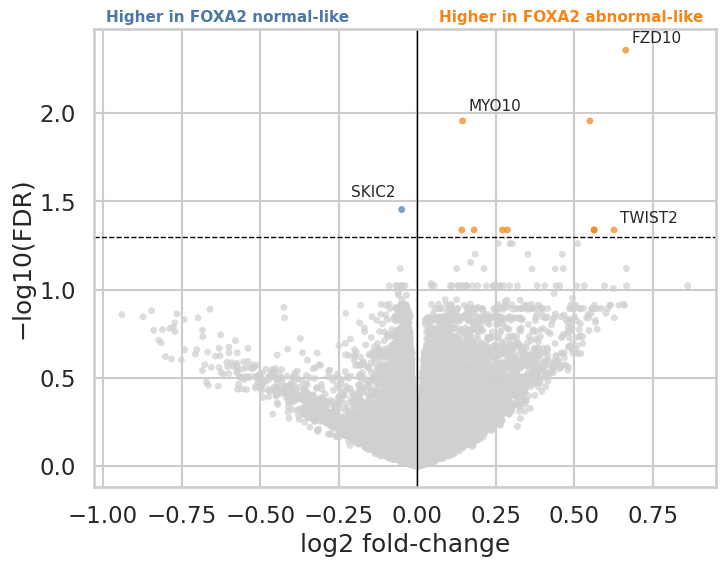

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/figures/02_volcano_limma_binary.png


In [3]:
import subprocess
import tempfile


def map_ensembl_to_symbol(ensembl_ids):
    ids = sorted({str(x).split('.')[0] for x in ensembl_ids if pd.notna(x) and str(x).strip()})
    if len(ids) == 0:
        return {}

    with tempfile.TemporaryDirectory() as td:
        ids_path = Path(td) / 'ids.txt'
        out_path = Path(td) / 'mapping.csv'
        ids_path.write_text('\n'.join(ids) + '\n')

        r_code = f"""
        suppressPackageStartupMessages({{
          library(data.table)
          library(AnnotationDbi)
          library(org.Hs.eg.db)
        }})
        ids <- readLines('{str(ids_path)}')
        m <- as.data.table(AnnotationDbi::select(
          org.Hs.eg.db,
          keys = ids,
          keytype = 'ENSEMBL',
          columns = c('ENSEMBL','SYMBOL')
        ))
        m <- m[!is.na(SYMBOL) & SYMBOL != '']
        m <- unique(m, by = c('ENSEMBL','SYMBOL'))
        fwrite(m, '{str(out_path)}')
        """

        subprocess.run(['Rscript', '-e', r_code], check=True)
        m = pd.read_csv(out_path)

    m = m.dropna(subset=['ENSEMBL', 'SYMBOL']).drop_duplicates(subset=['ENSEMBL'], keep='first')
    return dict(zip(m['ENSEMBL'].astype(str), m['SYMBOL'].astype(str)))


def make_volcano_limma_voom(df: pd.DataFrame) -> None:
    d = df.copy()
    d['logFC'] = pd.to_numeric(d['logFC'], errors='coerce')
    d['padj'] = pd.to_numeric(d['padj'], errors='coerce')
    d = d.dropna(subset=['logFC', 'padj']).copy()
    d = d[d['padj'] > 0].copy()

    d['neg_log10_fdr'] = -np.log10(d['padj'])
    d['is_sig'] = d['padj'] < ALPHA

    d['sig_direction'] = 'Not significant'
    d.loc[d['is_sig'] & (d['logFC'] < 0), 'sig_direction'] = 'Higher in normal-like'
    d.loc[d['is_sig'] & (d['logFC'] > 0), 'sig_direction'] = 'Higher in abnormal-like'

    d['gene_base'] = d['gene'].astype(str).str.split('.').str[0]
    sig = d[d['is_sig']].copy()

    symbol_map = {}
    if len(sig) > 0:
        try:
            symbol_map = map_ensembl_to_symbol(sig['gene_base'].tolist())
        except Exception:
            symbol_map = {}

    d['gene_symbol'] = d['gene_base'].map(symbol_map)

    palette = {
        'Not significant': '#D0D0D0',
        'Higher in normal-like': '#4C78A8',
        'Higher in abnormal-like': '#F58518',
    }

    fig, ax = plt.subplots(figsize=(7.6, 6.2))
    sns.scatterplot(
        data=d,
        x='logFC',
        y='neg_log10_fdr',
        hue='sig_direction',
        hue_order=['Not significant', 'Higher in normal-like', 'Higher in abnormal-like'],
        palette=palette,
        alpha=0.72,
        s=20,
        edgecolor=None,
        legend=False,
        ax=ax,
    )

    ax.axhline(-np.log10(ALPHA), linestyle='--', linewidth=1.0, color='black')
    ax.axvline(0.0, linewidth=1.0, color='black')

    ax.set_xlabel('log2 fold-change')
    ax.set_ylabel('−log10(FDR)')

    ax.text(0.02, 1.01, 'Higher in FOXA2 normal-like', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=11, fontweight='bold', color='#4C78A8', clip_on=False)
    ax.text(0.98, 1.01, 'Higher in FOXA2 abnormal-like', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=11, fontweight='bold', color='#F58518', clip_on=False)

    # Label a small, fixed set of representative genes.
    keep_labels = {'SKIC2', 'MYO10', 'FZD10', 'TWIST2'}
    label_df = d[d['is_sig']].copy()
    label_df = label_df[
        label_df.apply(
            lambda r: (
                (isinstance(r['gene_symbol'], str) and r['gene_symbol'].upper() in keep_labels)
                or (str(r['gene_base']).upper() in keep_labels)
            ),
            axis=1,
        )
    ].sort_values('padj')
    y_span = max(0.2, float(label_df['neg_log10_fdr'].max() - label_df['neg_log10_fdr'].min()) if len(label_df) else 0.2)
    for i, row in enumerate(label_df.itertuples(index=False)):
        label = row.gene_symbol if isinstance(row.gene_symbol, str) and row.gene_symbol else row.gene_base
        y_off = (0.025 + 0.015 * (i % 3)) * y_span
        x_off = 0.02 if row.logFC >= 0 else -0.02
        ha = 'left' if row.logFC >= 0 else 'right'
        ax.text(row.logFC + x_off, row.neg_log10_fdr + y_off, label, fontsize=11, ha=ha, va='bottom')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out_path = FIG_DIR / '02_volcano_limma_binary.png'
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved:', out_path)


make_volcano_limma_voom(step5)



## 3) Representative Gene Expression Panel


/tmp/ipykernel_219317/4260606237.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expr_long.groupby(['symbol', 'group_display'], as_index=False)


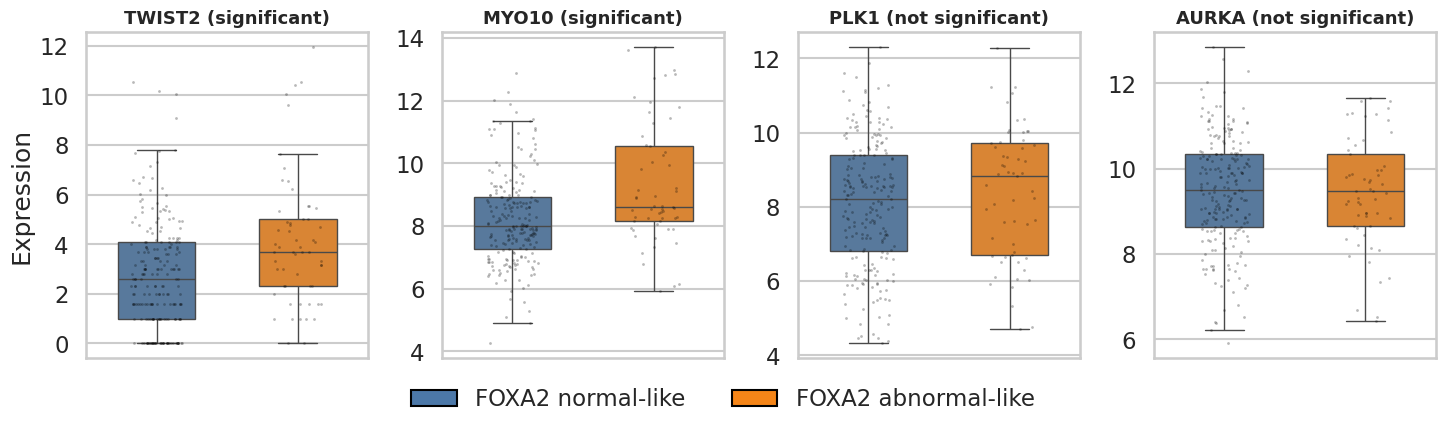

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/figures/03_representative_gene_expression_panel.png


,symbol,group_display,n_samples,median_expression,mean_expression,padj,is_significant
0,AURKA,Normal-like,215,9.509775,9.476073,0.422690,False
1,AURKA,Abnormal-like,57,9.475733,9.449608,0.422690,False
2,MYO10,Normal-like,215,7.994353,8.212018,0.011055,True
3,MYO10,Abnormal-like,57,8.592457,9.307744,0.011055,True
4,PLK1,Normal-like,215,8.209453,8.073728,0.989586,False
5,PLK1,Abnormal-like,57,8.826548,8.368340,0.989586,False
6,TWIST2,Normal-like,215,2.584963,2.762042,0.045842,True
7,TWIST2,Abnormal-like,57,3.700440,4.130923,0.045842,True


In [4]:
# Representative gene-expression panel (single row, four genes).
gene_panel = [
    {'symbol': 'TWIST2', 'ensembl_base': 'ENSG00000233608'},
    {'symbol': 'MYO10', 'ensembl_base': 'ENSG00000145555'},
    {'symbol': 'PLK1', 'ensembl_base': 'ENSG00000166851'},
    {'symbol': 'AURKA', 'ensembl_base': 'ENSG00000087586'},
]
panel_df = pd.DataFrame(gene_panel)
counts = pd.read_csv(COUNTS_PATH, sep='	')
counts['gene_base'] = counts['Ensembl_ID'].astype(str).str.split('.').str[0]
sample_cols = [c for c in counts.columns if c not in ['Ensembl_ID', 'gene_base']]
renamed = {c: str(c)[:15] for c in sample_cols}
counts = counts.rename(columns=renamed)
panel_counts = counts[counts['gene_base'].isin(set(panel_df['ensembl_base']))].copy()
if panel_counts.empty:
    raise ValueError('No panel genes were found in the counts matrix.')
labels_small = labels[['sample', 'group']].copy()
available_samples = [s for s in labels_small['sample'].astype(str).tolist() if s in panel_counts.columns]
if not available_samples:
    raise ValueError('No overlap between sample labels and counts columns for panel plotting.')
expr_long = panel_counts[['gene_base'] + available_samples].melt(
    id_vars='gene_base',
    var_name='sample',
    value_name='expression',
)
expr_long['expression'] = pd.to_numeric(expr_long['expression'], errors='coerce')
expr_long = expr_long.dropna(subset=['expression'])
expr_long = expr_long.merge(panel_df, left_on='gene_base', right_on='ensembl_base', how='left')
expr_long = expr_long.merge(labels_small, on='sample', how='inner')
group_order = ['foxa2_normal_pos', 'foxa2_abnormal_zero']
display_order = ['Normal-like', 'Abnormal-like']
display_labels = {'foxa2_normal_pos': 'Normal-like', 'foxa2_abnormal_zero': 'Abnormal-like'}
expr_long['group_display'] = expr_long['group'].map(display_labels)
expr_long['group'] = pd.Categorical(expr_long['group'], categories=group_order, ordered=True)
expr_long['group_display'] = pd.Categorical(expr_long['group_display'], categories=display_order, ordered=True)
# Significance from limma-voom step5 results.
step5_sig = step5.copy()
step5_sig['gene_base'] = step5_sig['gene'].astype(str).str.split('.').str[0]
step5_sig['padj'] = pd.to_numeric(step5_sig['padj'], errors='coerce')
step5_sig = step5_sig.dropna(subset=['padj']).drop_duplicates(subset=['gene_base'])
panel_df = panel_df.merge(step5_sig[['gene_base', 'padj']], left_on='ensembl_base', right_on='gene_base', how='left')
panel_df['is_significant'] = panel_df['padj'] < ALPHA
summary = (
    expr_long.groupby(['symbol', 'group_display'], as_index=False)
    .agg(n_samples=('expression', 'size'), median_expression=('expression', 'median'), mean_expression=('expression', 'mean'))
)
summary = summary.merge(panel_df[['symbol', 'padj', 'is_significant']], on='symbol', how='left')
summary.to_csv(DATA_DIR / '08_representative_gene_expression_summary.csv', index=False)
plot_order = [g['symbol'] for g in gene_panel]
from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 4, figsize=(14.8, 4.4), sharey=False)
axes = np.atleast_1d(axes)
palette = {'Normal-like': '#4C78A8', 'Abnormal-like': '#F58518'}
for i, (ax, symbol) in enumerate(zip(axes, plot_order)):
    sub = expr_long[expr_long['symbol'] == symbol].copy()
    sig_row = panel_df[panel_df['symbol'] == symbol].iloc[0]
    status = 'significant' if bool(sig_row['is_significant']) else 'not significant'
    sns.boxplot(
        data=sub,
        x='group_display',
        y='expression',
        hue='group_display',
        order=display_order,
        hue_order=display_order,
        dodge=False,
        palette=palette,
        width=0.55,
        fliersize=0,
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=sub,
        x='group_display',
        y='expression',
        order=display_order,
        color='black',
        alpha=0.28,
        size=2.0,
        jitter=0.18,
        ax=ax,
    )
    ax.set_title(f"{symbol} ({status})", fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    if i == 0:
        ax.set_ylabel('Expression')
    else:
        ax.set_ylabel('')
legend_handles = [
    Patch(facecolor=palette['Normal-like'], edgecolor='black', label='FOXA2 normal-like'),
    Patch(facecolor=palette['Abnormal-like'], edgecolor='black', label='FOXA2 abnormal-like'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
out = FIG_DIR / '03_representative_gene_expression_panel.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', out)
summary


## 4) GSEA Running Score Plots


'select()' returned 1:many mapping between keys and columns


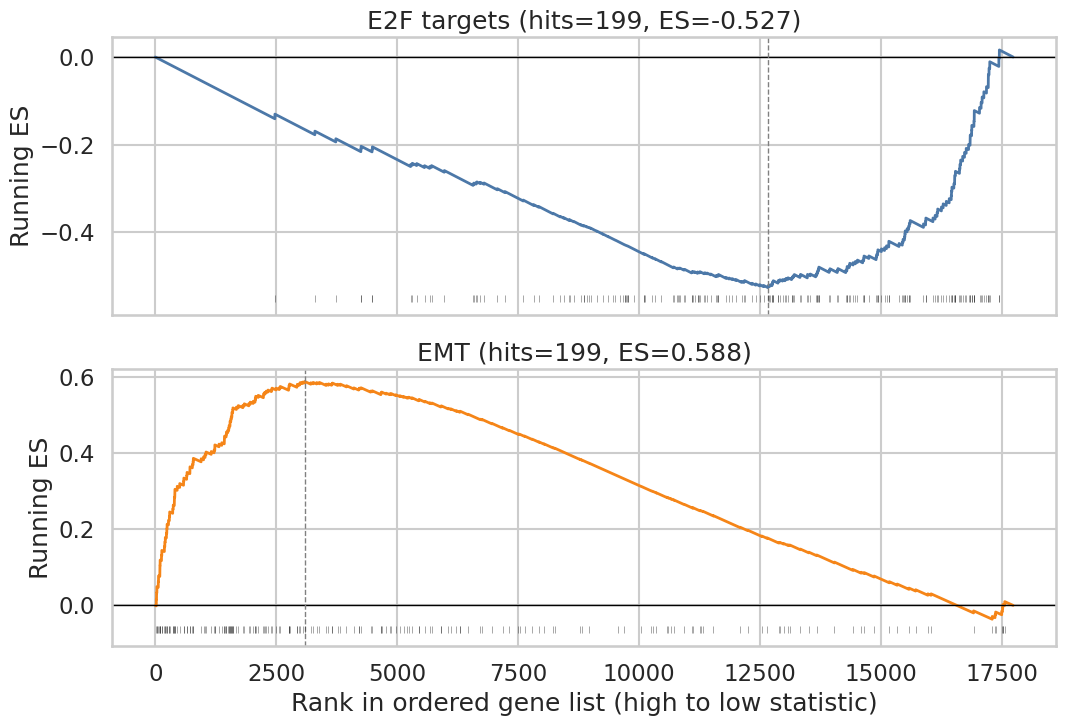

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/figures/04_gsea_running_score_plots.png


,pathway,pathway_label,n_hits_in_ranked_list,enrichment_score,peak_rank_position
0,HALLMARK_E2F_TARGETS,E2F targets,199,-0.526821,12662
1,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,EMT,199,0.587568,3088


In [5]:
import subprocess
import tempfile

selected_pathways = [
    'HALLMARK_E2F_TARGETS',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
]

with tempfile.TemporaryDirectory() as td:
    ranked_out = Path(td) / 'ranked_symbol_stats.csv'
    sets_out = Path(td) / 'selected_hallmark_sets.csv'

    r_script = f"""
    suppressPackageStartupMessages({{
      library(data.table)
      library(AnnotationDbi)
      library(org.Hs.eg.db)
      library(msigdbr)
    }})

    step1 <- fread('{str(STEP1_PATH)}')
    step1[, gene_base := sub('[.].*$', '', gene)]

    map <- as.data.table(AnnotationDbi::select(
      org.Hs.eg.db,
      keys = unique(step1$gene_base),
      keytype = 'ENSEMBL',
      columns = c('ENSEMBL', 'SYMBOL')
    ))
    map <- map[!is.na(SYMBOL) & SYMBOL != '']
    map <- unique(map, by = c('ENSEMBL', 'SYMBOL'))

    ranked <- merge(step1[, .(gene_base, stat)], map, by.x = 'gene_base', by.y = 'ENSEMBL', all = FALSE)
    ranked <- ranked[!is.na(stat)]
    ranked[, abs_stat := abs(stat)]
    setorder(ranked, -abs_stat)
    ranked <- ranked[, .SD[1], by = SYMBOL]
    setorder(ranked, -stat)
    fwrite(ranked[, .(symbol = SYMBOL, stat = stat)], '{str(ranked_out)}')

    hall <- as.data.table(msigdbr(species = 'Homo sapiens', collection = 'H'))
    pathways <- c({', '.join([repr(x) for x in selected_pathways])})
    hall_sel <- hall[gs_name %in% pathways, .(pathway = gs_name, symbol = gene_symbol)]
    fwrite(unique(hall_sel), '{str(sets_out)}')
    """

    subprocess.run(['Rscript', '-e', r_script], check=True)

    ranked = pd.read_csv(ranked_out)
    gene_sets = pd.read_csv(sets_out)

ranked = ranked.dropna(subset=['symbol', 'stat']).copy()
ranked['symbol'] = ranked['symbol'].astype(str)
ranked['stat'] = pd.to_numeric(ranked['stat'], errors='coerce')
ranked = ranked.dropna(subset=['stat']).sort_values('stat', ascending=False).reset_index(drop=True)

available = [p for p in selected_pathways if p in set(gene_sets['pathway'])]
plot_pathways = []
if 'HALLMARK_E2F_TARGETS' in available:
    plot_pathways.append('HALLMARK_E2F_TARGETS')
if 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION' in available:
    plot_pathways.append('HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION')
elif 'HALLMARK_TNFA_SIGNALING_VIA_NFKB' in available:
    plot_pathways.append('HALLMARK_TNFA_SIGNALING_VIA_NFKB')

if len(plot_pathways) == 0:
    raise ValueError('No selected hallmark pathways found for running-score plot.')


def running_enrichment_curve(ranked_df: pd.DataFrame, pathway_symbols: set[str], p: float = 1.0):
    stats = ranked_df['stat'].to_numpy(dtype=float)
    genes = ranked_df['symbol'].astype(str).to_numpy()
    hits = np.array([g in pathway_symbols for g in genes], dtype=bool)

    n = len(genes)
    nh = int(hits.sum())
    nm = n - nh
    if nh == 0 or nm == 0:
        raise ValueError('Pathway has zero hits or full hits in ranked list.')

    weights = np.abs(stats) ** p
    hit_weights = weights[hits]
    norm_hit = hit_weights / hit_weights.sum()

    increments = np.full(n, -1.0 / nm)
    increments[hits] = norm_hit
    running = np.cumsum(increments)

    es_max = float(running.max())
    es_min = float(running.min())
    es = es_max if abs(es_max) >= abs(es_min) else es_min
    peak_idx = int(np.argmax(np.abs(running)))
    hit_positions = np.where(hits)[0]
    return running, hit_positions, es, peak_idx, nh

label_map = {
    'HALLMARK_E2F_TARGETS': 'E2F targets',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION': 'EMT',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB': 'TNFA/NFKB signalling',
}

summary_rows = []
fig, axes = plt.subplots(len(plot_pathways), 1, figsize=(11, 3.8 * len(plot_pathways)), sharex=True)
if len(plot_pathways) == 1:
    axes = [axes]

for ax, pathway in zip(axes, plot_pathways):
    symbols = set(gene_sets.loc[gene_sets['pathway'] == pathway, 'symbol'].astype(str))
    running, hit_pos, es, peak_idx, nh = running_enrichment_curve(ranked, symbols, p=1.0)

    x = np.arange(1, len(ranked) + 1)
    colour = '#4C78A8' if es < 0 else '#F58518'
    ax.plot(x, running, color=colour, linewidth=2)
    ax.axhline(0.0, color='black', linewidth=1)
    ax.axvline(peak_idx + 1, color='grey', linestyle='--', linewidth=1)

    if len(hit_pos) > 0:
        y0 = running.min() - 0.06 * (running.max() - running.min() + 1e-9)
        ax.vlines(hit_pos + 1, y0, y0 + 0.03 * (running.max() - running.min() + 1e-9), color='black', linewidth=0.4, alpha=0.6)

    ax.set_ylabel('Running ES')
    pathway_label = label_map.get(pathway, pathway)
    ax.set_title(f'{pathway_label} (hits={nh}, ES={es:.3f})')

    summary_rows.append({
        'pathway': pathway,
        'pathway_label': pathway_label,
        'n_hits_in_ranked_list': nh,
        'enrichment_score': es,
        'peak_rank_position': int(peak_idx + 1),
    })

axes[-1].set_xlabel('Rank in ordered gene list (high to low statistic)')
plt.tight_layout()
out = FIG_DIR / '04_gsea_running_score_plots.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', out)

running_summary = pd.DataFrame(summary_rows)
running_summary.to_csv(DATA_DIR / '09_gsea_running_score_summary.csv', index=False)
running_summary



## 5) Method Agreement at Gene Level


In [6]:
def n_sig(df: pd.DataFrame, padj_col: str = 'padj', alpha: float = ALPHA) -> int:
    if padj_col not in df.columns:
        return 0
    d = pd.to_numeric(df[padj_col], errors='coerce')
    return int((d < alpha).sum())

method_summary = pd.DataFrame([
    {'analysis': 'Binary DESeq2 (primary)', 'tested_features': len(deseq), 'significant_fdr_0_05': n_sig(deseq)},
    {'analysis': 'Binary limma (primary)', 'tested_features': len(limma), 'significant_fdr_0_05': n_sig(limma)},
    {'analysis': 'Continuous DESeq2 (step 1)', 'tested_features': len(step1), 'significant_fdr_0_05': n_sig(step1)},
    {'analysis': 'Continuous DESeq2 + SVA (step 3)', 'tested_features': len(step3), 'significant_fdr_0_05': n_sig(step3)},
    {'analysis': 'Hallmark-universe DESeq2 (step 4)', 'tested_features': len(step4), 'significant_fdr_0_05': n_sig(step4)},
    {'analysis': 'Binary limma-voom (step 5 sensitivity)', 'tested_features': len(step5), 'significant_fdr_0_05': n_sig(step5)},
])
method_summary.to_csv(DATA_DIR / '01_method_significance_summary.csv', index=False)
method_summary


,analysis,tested_features,significant_fdr_0_05
0,Binary DESeq2 (primary),9006,0
1,Binary limma (primary),20218,4
2,Continuous DESeq2 (step 1),20279,0
3,Continuous DESeq2 + SVA (step 3),20279,0
4,Hallmark-universe DESeq2 (step 4),4138,0
5,Binary limma-voom (step 5 sensitivity),20279,11


In [7]:
print('Skipped: method-agreement bar plot removed to reduce noise.')


Skipped: method-agreement bar plot removed to reduce noise.


In [8]:
print('Skipped: overlap bar plot removed to reduce noise.')


Skipped: overlap bar plot removed to reduce noise.


In [9]:
print('Skipped: effect-size scatter plot removed to reduce noise.')


Skipped: effect-size scatter plot removed to reduce noise.


## 6) Sensitivity and Reporting Tables


In [10]:
def summarise_gene_model(df: pd.DataFrame, lfc_col: str, p_col: str, label: str) -> dict:
    p = pd.to_numeric(df[p_col], errors='coerce')
    lfc = pd.to_numeric(df[lfc_col], errors='coerce')
    return {
        'analysis': label,
        'features_tested': int(len(df)),
        'significant_fdr_0_05': int((p < ALPHA).sum()),
        'min_padj': float(p.min(skipna=True)) if p.notna().any() else np.nan,
        'median_abs_effect': float(lfc.abs().median(skipna=True)) if lfc.notna().any() else np.nan,
    }

sensitivity = pd.DataFrame([
    summarise_gene_model(deseq, 'log2FoldChange', 'padj', 'Primary binary DESeq2'),
    summarise_gene_model(limma, 'logFC', 'padj', 'Primary binary limma'),
    summarise_gene_model(step1, 'log2FoldChange', 'padj', 'Step 1 continuous DESeq2'),
    summarise_gene_model(step3, 'log2FoldChange', 'padj', 'Step 3 continuous DESeq2 + SVA'),
    summarise_gene_model(step4, 'log2FoldChange', 'padj', 'Step 4 Hallmark-universe DESeq2'),
    summarise_gene_model(step5, 'logFC', 'padj', 'Step 5 limma-voom binary sensitivity'),
])
sensitivity.to_csv(DATA_DIR / '04_gene_model_sensitivity_summary.csv', index=False)

fgsea_summary = pd.DataFrame([
    {
        'analysis': 'Step 2 FGSEA Hallmark',
        'pathways_tested': int(len(fgsea)),
        'significant_fdr_0_05': int((fgsea['padj'] < ALPHA).sum()),
        'best_pathway': fgsea.sort_values('padj').iloc[0]['pathway'],
        'best_pathway_padj': float(fgsea['padj'].min()),
    }
])
fgsea_summary.to_csv(DATA_DIR / '05_fgsea_summary.csv', index=False)

limma_sig = limma[limma['padj'] < ALPHA].sort_values('padj').copy()
limma_sig.to_csv(DATA_DIR / '06_primary_limma_significant_genes.csv', index=False)

warnings_table = pd.DataFrame([
    {'item': 'DESeq2 beta convergence', 'status': 'One row did not converge in beta', 'impact': 'Low; isolated row-level warning'},
    {'item': 'Dispersion fit fallback', 'status': 'Parametric trend substituted with local fit', 'impact': 'Low; model fit handled automatically'},
    {'item': 'Annotation mapping', 'status': '1:many mapping warning from select()', 'impact': 'Low; annotation-level mapping note'},
    {'item': 'msigdbr deprecation', 'status': 'category argument deprecated in favour of collection', 'impact': 'None on current results; update script for future-proofing'},
])
warnings_table.to_csv(DATA_DIR / '07_warnings_and_limitations.csv', index=False)

print('Saved tables:')
for p in [
    DATA_DIR / '04_gene_model_sensitivity_summary.csv',
    DATA_DIR / '05_fgsea_summary.csv',
    DATA_DIR / '06_primary_limma_significant_genes.csv',
    DATA_DIR / '07_warnings_and_limitations.csv',
]:
    print('-', p)

sensitivity


Saved tables:
- /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/data/04_gene_model_sensitivity_summary.csv
- /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/data/05_fgsea_summary.csv
- /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/data/06_primary_limma_significant_genes.csv
- /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/data/07_warnings_and_limitations.csv


,analysis,features_tested,significant_fdr_0_05,min_padj,median_abs_effect
0,Primary binary DESeq2,9006,0,0.999943,0.015429
1,Primary binary limma,20218,4,0.021218,0.029500
2,Step 1 continuous DESeq2,20279,0,0.999996,0.012300
3,Step 3 continuous DESeq2 + SVA,20279,0,0.999986,0.009109
4,Step 4 Hallmark-universe DESeq2,4138,0,0.999930,0.009547
5,Step 5 limma-voom binary sensitivity,20279,11,0.004395,0.027569


In [11]:
print('Skipped: sensitivity point plot removed to reduce noise.')


Skipped: sensitivity point plot removed to reduce noise.


## Final thesis-ready plots

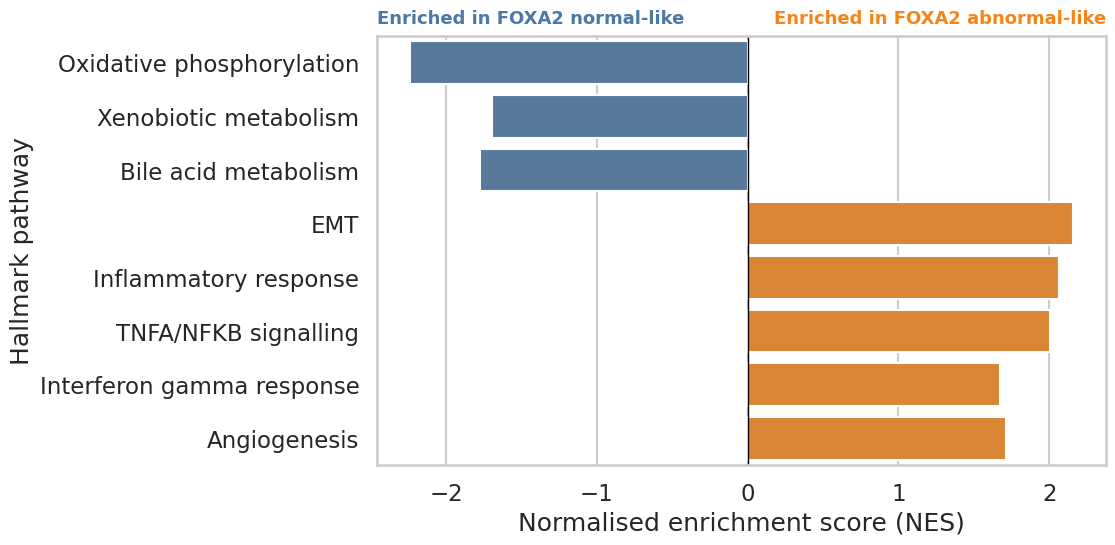

'select()' returned 1:many mapping between keys and columns


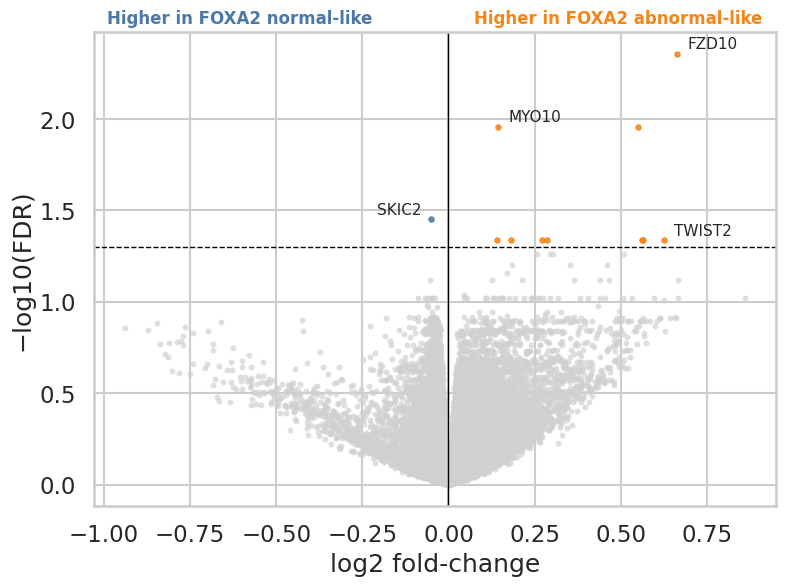

'select()' returned 1:many mapping between keys and columns


/tmp/ipykernel_219317/2935484967.py:264: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = expr_long.groupby(['symbol', 'group_display'], as_index=False)['expression'].median()
/tmp/ipykernel_219317/2935484967.py:362: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_219317/2935484967.py:362: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_219317/2935484967.py:362: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

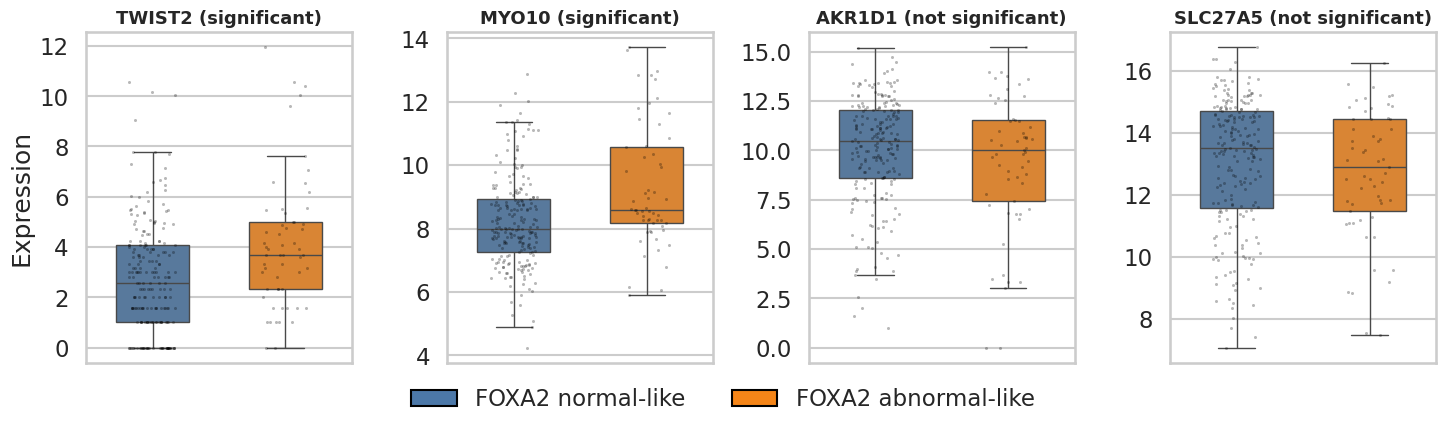

Saved final plots:
- /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/figures/final_pathway_barplot.png
- /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/figures/final_limma_voom_volcano.png
- /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/figures/final_representative_gene_expression.png
Saved final gene-selection table:
- /home/lem/projects/mut-epi-origin/outputs/thesis/03_differential_expression/data/final_representative_gene_selection.csv


In [12]:

# Final standalone figures for thesis assembly.

FINAL_FIG_DIR = FIG_DIR
FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

FOXA2_PALETTE = {
    'normal_like': '#4C78A8',
    'abnormal_like': '#F58518',
    'nonsig': '#D0D0D0',
}


def plot_final_pathway_barplot(fgsea_df: pd.DataFrame) -> Path:
    normal_like_pathways = [
        'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
        'HALLMARK_XENOBIOTIC_METABOLISM',
        'HALLMARK_BILE_ACID_METABOLISM',
    ]
    abnormal_like_pathways = [
        'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
        'HALLMARK_INFLAMMATORY_RESPONSE',
        'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
        'HALLMARK_INTERFERON_GAMMA_RESPONSE',
        'HALLMARK_ANGIOGENESIS',
    ]
    pathway_order = normal_like_pathways + abnormal_like_pathways
    display_map = {
        'HALLMARK_OXIDATIVE_PHOSPHORYLATION': 'Oxidative phosphorylation',
        'HALLMARK_XENOBIOTIC_METABOLISM': 'Xenobiotic metabolism',
        'HALLMARK_BILE_ACID_METABOLISM': 'Bile acid metabolism',
        'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION': 'EMT',
        'HALLMARK_INFLAMMATORY_RESPONSE': 'Inflammatory response',
        'HALLMARK_TNFA_SIGNALING_VIA_NFKB': 'TNFA/NFKB signalling',
        'HALLMARK_INTERFERON_GAMMA_RESPONSE': 'Interferon gamma response',
        'HALLMARK_ANGIOGENESIS': 'Angiogenesis',
    }

    d = fgsea_df.copy()
    d['padj'] = pd.to_numeric(d['padj'], errors='coerce')
    d['NES'] = pd.to_numeric(d['NES'], errors='coerce')
    d = d.dropna(subset=['pathway', 'padj', 'NES'])

    d = d[d['pathway'].isin(pathway_order)].sort_values('padj').drop_duplicates('pathway', keep='first')
    missing = [p for p in pathway_order if p not in set(d['pathway'])]
    if missing:
        raise ValueError(f'Missing required Hallmark pathways: {missing}')

    d = d.set_index('pathway').loc[pathway_order].reset_index()
    non_sig = d[d['padj'] >= ALPHA][['pathway', 'padj']]
    if len(non_sig) > 0:
        raise ValueError(
            'Required pathways not significant at FDR < 0.05: '
            + ', '.join([f"{r.pathway} (padj={r.padj:.4g})" for r in non_sig.itertuples(index=False)])
        )

    d['side'] = np.where(
        d['pathway'].isin(normal_like_pathways),
        'Enriched in FOXA2 normal-like',
        'Enriched in FOXA2 abnormal-like',
    )
    d['plot_nes'] = np.where(
        d['pathway'].isin(normal_like_pathways),
        -d['NES'].abs(),
        d['NES'].abs(),
    )
    d['pathway_label'] = d['pathway'].map(display_map)

    fig, ax = plt.subplots(figsize=(11.5, 5.8))
    sns.barplot(
        data=d,
        y='pathway_label',
        x='plot_nes',
        hue='side',
        dodge=False,
        hue_order=['Enriched in FOXA2 normal-like', 'Enriched in FOXA2 abnormal-like'],
        palette={
            'Enriched in FOXA2 normal-like': FOXA2_PALETTE['normal_like'],
            'Enriched in FOXA2 abnormal-like': FOXA2_PALETTE['abnormal_like'],
        },
        ax=ax,
    )
    ax.axvline(0.0, color='black', linewidth=1.0)
    ax.set_xlabel('Normalised enrichment score (NES)')
    ax.set_ylabel('Hallmark pathway')
    ax.text(
        0.0,
        1.02,
        'Enriched in FOXA2 normal-like',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color=FOXA2_PALETTE['normal_like'],
    )
    ax.text(
        1.0,
        1.02,
        'Enriched in FOXA2 abnormal-like',
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color=FOXA2_PALETTE['abnormal_like'],
    )
    if ax.legend_ is not None:
        ax.legend_.remove()
    plt.tight_layout()

    out = FINAL_FIG_DIR / 'final_pathway_barplot.png'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return out


def plot_final_limma_voom_volcano(step5_df: pd.DataFrame) -> Path:
    d = step5_df.copy()
    d['logFC'] = pd.to_numeric(d['logFC'], errors='coerce')
    d['padj'] = pd.to_numeric(d['padj'], errors='coerce')
    d = d.dropna(subset=['logFC', 'padj'])
    d = d[d['padj'] > 0].copy()

    d['neg_log10_fdr'] = -np.log10(d['padj'])
    d['is_sig'] = d['padj'] < ALPHA
    d['sig_direction'] = 'Not significant'
    d.loc[d['is_sig'] & (d['logFC'] < 0), 'sig_direction'] = 'Higher in FOXA2 normal-like'
    d.loc[d['is_sig'] & (d['logFC'] > 0), 'sig_direction'] = 'Higher in FOXA2 abnormal-like'

    d['gene_base'] = d['gene'].astype(str).str.split('.').str[0]
    symbol_map = {}
    try:
        symbol_map = map_ensembl_to_symbol(d['gene_base'].tolist())
    except Exception:
        symbol_map = {}
    d['gene_symbol'] = d['gene_base'].map(symbol_map)

    fig, ax = plt.subplots(figsize=(8.2, 6.4))
    non_sig = d[d['sig_direction'] == 'Not significant']
    sig_norm = d[d['sig_direction'] == 'Higher in FOXA2 normal-like']
    sig_abn = d[d['sig_direction'] == 'Higher in FOXA2 abnormal-like']

    ax.scatter(non_sig['logFC'], non_sig['neg_log10_fdr'], s=18, alpha=0.7, c=FOXA2_PALETTE['nonsig'], linewidths=0)
    ax.scatter(sig_norm['logFC'], sig_norm['neg_log10_fdr'], s=22, alpha=0.9, c=FOXA2_PALETTE['normal_like'], linewidths=0)
    ax.scatter(sig_abn['logFC'], sig_abn['neg_log10_fdr'], s=22, alpha=0.9, c=FOXA2_PALETTE['abnormal_like'], linewidths=0)

    ax.axvline(0.0, color='black', linewidth=1.0)
    ax.axhline(-np.log10(ALPHA), color='black', linestyle='--', linewidth=1.0)
    ax.set_xlabel('log2 fold-change')
    ax.set_ylabel('−log10(FDR)')

    ax.text(
        0.02,
        1.01,
        'Higher in FOXA2 normal-like',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color=FOXA2_PALETTE['normal_like'],
        clip_on=False,
    )
    ax.text(
        0.98,
        1.01,
        'Higher in FOXA2 abnormal-like',
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color=FOXA2_PALETTE['abnormal_like'],
        clip_on=False,
    )

    target_labels = {'TWIST2', 'MYO10', 'FZD10', 'SKIC2'}
    d['label_symbol'] = np.where(d['gene_symbol'].notna(), d['gene_symbol'], d['gene_base'])
    label_df = d[
        d['label_symbol'].astype(str).str.upper().isin(target_labels)
        | d['gene_base'].astype(str).str.upper().isin(target_labels)
    ].sort_values('padj').drop_duplicates('label_symbol', keep='first')

    label_nudges = {
        'TWIST2': (0.03, 0.03, 'left'),
        'MYO10': (0.03, 0.05, 'left'),
        'FZD10': (0.03, 0.06, 'left'),
        'SKIC2': (-0.03, 0.03, 'right'),
    }
    y_span = max(0.3, float(d['neg_log10_fdr'].max() - d['neg_log10_fdr'].min()))
    for row in label_df.itertuples(index=False):
        label = str(row.label_symbol)
        key = label.upper()
        x_off, y_off, ha = label_nudges.get(key, (0.02 if row.logFC >= 0 else -0.02, 0.03, 'left' if row.logFC >= 0 else 'right'))
        ax.text(row.logFC + x_off, row.neg_log10_fdr + (y_off * y_span * 0.1), label, fontsize=11, ha=ha, va='bottom')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = FINAL_FIG_DIR / 'final_limma_voom_volcano.png'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return out


def _build_symbol_to_ensembl_map(step5_df: pd.DataFrame) -> dict:
    bases = step5_df['gene'].astype(str).str.split('.').str[0].tolist()
    try:
        ensembl_to_symbol = map_ensembl_to_symbol(bases)
    except Exception:
        ensembl_to_symbol = {}
    symbol_to_ensembl = {}
    for ensembl, symbol in ensembl_to_symbol.items():
        if isinstance(symbol, str) and symbol and symbol not in symbol_to_ensembl:
            symbol_to_ensembl[symbol] = ensembl
    return symbol_to_ensembl


def _build_expression_long_for_symbols(symbols: list[str], symbol_to_ensembl: dict) -> pd.DataFrame:
    requested = [s for s in symbols if s in symbol_to_ensembl]
    if len(requested) == 0:
        raise ValueError('None of the requested symbols could be mapped to Ensembl IDs in limma results.')

    panel_df = pd.DataFrame(
        [{'symbol': s, 'ensembl_base': symbol_to_ensembl[s]} for s in requested]
    )
    counts = pd.read_csv(COUNTS_PATH, sep='	')
    counts['gene_base'] = counts['Ensembl_ID'].astype(str).str.split('.').str[0]

    sample_cols = [c for c in counts.columns if c not in ['Ensembl_ID', 'gene_base']]
    renamed = {c: str(c)[:15] for c in sample_cols}
    counts = counts.rename(columns=renamed)

    labels_small = labels[['sample', 'group']].copy()
    available_samples = [s for s in labels_small['sample'].astype(str).tolist() if s in counts.columns]
    if len(available_samples) == 0:
        raise ValueError('No overlap between sample labels and count matrix columns.')

    panel_counts = counts[counts['gene_base'].isin(set(panel_df['ensembl_base']))].copy()
    expr_long = panel_counts[['gene_base'] + available_samples].melt(
        id_vars='gene_base',
        var_name='sample',
        value_name='expression',
    )
    expr_long['expression'] = pd.to_numeric(expr_long['expression'], errors='coerce')
    expr_long = expr_long.dropna(subset=['expression'])
    expr_long = expr_long.merge(panel_df, left_on='gene_base', right_on='ensembl_base', how='inner')
    expr_long = expr_long.merge(labels_small, on='sample', how='inner')

    display_labels = {
        'foxa2_normal_pos': 'Normal-like',
        'foxa2_abnormal_zero': 'Abnormal-like',
    }
    expr_long['group_display'] = expr_long['group'].map(display_labels)
    expr_long['group_display'] = pd.Categorical(
        expr_long['group_display'],
        categories=['Normal-like', 'Abnormal-like'],
        ordered=True,
    )
    return expr_long


def _select_final_gene_panel(expr_long: pd.DataFrame) -> list[str]:
    med = expr_long.groupby(['symbol', 'group_display'], as_index=False)['expression'].median()
    med_wide = med.pivot(index='symbol', columns='group_display', values='expression').reset_index()
    med_wide['delta_normal_minus_abnormal'] = med_wide['Normal-like'] - med_wide['Abnormal-like']

    delta_map = dict(zip(med_wide['symbol'], med_wide['delta_normal_minus_abnormal']))
    present = set(expr_long['symbol'].unique())

    abnormal_priority = ['TWIST2', 'MYO10', 'FZD10', 'SPINT2']
    normal_priority = ['GNMT', 'AKR1D1', 'SLC27A5', 'APOA1', 'AOX1', 'TAT', 'RBP4', 'FETUB']

    selected_abnormal = []
    for gene in abnormal_priority:
        if gene in present and delta_map.get(gene, np.nan) < 0:
            selected_abnormal.append(gene)
        if len(selected_abnormal) == 2:
            break
    if len(selected_abnormal) < 2:
        for gene in abnormal_priority:
            if gene in present and gene not in selected_abnormal:
                selected_abnormal.append(gene)
            if len(selected_abnormal) == 2:
                break

    selected_normal = []
    for gene in normal_priority:
        if gene in present and delta_map.get(gene, np.nan) > 0:
            selected_normal.append(gene)
        if len(selected_normal) == 2:
            break

    if len(selected_normal) < 2:
        ranked = (
            med_wide[med_wide['symbol'].isin(normal_priority)]
            .sort_values('delta_normal_minus_abnormal', ascending=False)['symbol']
            .tolist()
        )
        for gene in ranked:
            if gene in present and gene not in selected_normal:
                selected_normal.append(gene)
            if len(selected_normal) == 2:
                break

    final_genes = selected_abnormal[:2] + selected_normal[:2]
    if len(final_genes) < 4:
        remaining = [g for g in abnormal_priority + normal_priority if g in present and g not in final_genes]
        final_genes.extend(remaining[: 4 - len(final_genes)])

    if len(final_genes) < 4:
        raise ValueError('Could not select four representative genes from the requested candidate sets.')

    return final_genes[:4]


def plot_final_representative_expression(step5_df: pd.DataFrame) -> tuple[Path, Path]:
    symbol_to_ensembl = _build_symbol_to_ensembl_map(step5_df)

    candidate_symbols = [
        'TWIST2', 'MYO10', 'GNMT', 'AKR1D1',
        'SLC27A5', 'APOA1', 'AOX1', 'TAT', 'RBP4', 'FETUB',
        'FZD10', 'SPINT2',
    ]
    expr_long = _build_expression_long_for_symbols(candidate_symbols, symbol_to_ensembl)

    final_genes = _select_final_gene_panel(expr_long)
    selected = expr_long[expr_long['symbol'].isin(final_genes)].copy()

    med = (
        selected.groupby(['symbol', 'group_display'], as_index=False, observed=False)['expression']
        .median()
        .pivot(index='symbol', columns='group_display', values='expression')
        .reset_index()
    )
    med['delta_normal_minus_abnormal'] = med['Normal-like'] - med['Abnormal-like']
    med = med.set_index('symbol').loc[final_genes].reset_index()

    step5_sig = step5_df.copy()
    step5_sig['gene_base'] = step5_sig['gene'].astype(str).str.split('.').str[0]
    step5_sig['padj'] = pd.to_numeric(step5_sig['padj'], errors='coerce')
    step5_sig = step5_sig.dropna(subset=['padj'])
    significance_by_symbol = {}
    for symbol in final_genes:
        ensembl = symbol_to_ensembl.get(symbol)
        if ensembl is None:
            significance_by_symbol[symbol] = False
            continue
        gene_rows = step5_sig[step5_sig['gene_base'] == ensembl]
        significance_by_symbol[symbol] = bool((gene_rows['padj'] < ALPHA).any()) if len(gene_rows) > 0 else False

    from matplotlib.patches import Patch
    fig, axes = plt.subplots(1, 4, figsize=(14.8, 4.4), sharey=False)
    axes = np.atleast_1d(axes)
    palette = {
        'Normal-like': FOXA2_PALETTE['normal_like'],
        'Abnormal-like': FOXA2_PALETTE['abnormal_like'],
    }

    for ax, symbol in zip(axes, final_genes):
        sub = selected[selected['symbol'] == symbol].copy()
        sns.boxplot(
            data=sub,
            x='group_display',
            y='expression',
            order=['Normal-like', 'Abnormal-like'],
            palette=palette,
            width=0.55,
            fliersize=0,
            ax=ax,
        )
        sns.stripplot(
            data=sub,
            x='group_display',
            y='expression',
            order=['Normal-like', 'Abnormal-like'],
            color='black',
            alpha=0.28,
            size=2.2,
            jitter=0.18,
            ax=ax,
        )
        status = 'significant' if significance_by_symbol.get(symbol, False) else 'not significant'
        ax.set_title(f"{symbol} ({status})", fontsize=13, fontweight='bold')
        ax.set_xlabel('')
        ax.set_xticklabels([])
        ax.tick_params(axis='x', length=0)
        if symbol == final_genes[0]:
            ax.set_ylabel('Expression')
        else:
            ax.set_ylabel('')

    legend_handles = [
        Patch(facecolor=palette['Normal-like'], edgecolor='black', label='FOXA2 normal-like'),
        Patch(facecolor=palette['Abnormal-like'], edgecolor='black', label='FOXA2 abnormal-like'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    out_fig = FINAL_FIG_DIR / 'final_representative_gene_expression.png'
    fig.savefig(out_fig, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    out_table = DATA_DIR / 'final_representative_gene_selection.csv'
    med.to_csv(out_table, index=False)

    return out_fig, out_table


pathway_out = plot_final_pathway_barplot(fgsea)
volcano_out = plot_final_limma_voom_volcano(step5)
expr_out, expr_table_out = plot_final_representative_expression(step5)

print('Saved final plots:')
print('-', pathway_out)
print('-', volcano_out)
print('-', expr_out)
print('Saved final gene-selection table:')
print('-', expr_table_out)
